In [1]:
# Importer les packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# gérer les warnings
import warnings
warnings.filterwarnings("ignore")

### <font color = 'bisque'> Importer et lire les données

In [3]:
#from google.colab import drive
#drive.mount('/content/drive')

In [4]:
# Importer les données
df = pd.read_csv('/kaggle/input/datasets/oumarodjiguimde/document-1/Car_Data.csv')

Les données ont été scrapées de la page https://www.expat-dakar.com/voitures/dakar. Ce sont des données de vehicules en vente à Dakar.
L'objectif de ce TP est de mettre en place un modèle classification qui en partant de certaines caractéristiques d'une voiture nous prédira si celle-ci est venante ou d'occassion.





In [5]:
# Afficher les données
df.head()

,Marque,Année,Boite_Vitesse,Adresse,Prix,Venant_Occasion
0,Mitsubishi,2017,Automatique,"Liberte 6,Dakar",9750000,Venant
1,Ford,2009,Manuelle,"Yoff,Dakar",2500000,D'occasion
2,BMW,2015,Automatique,"Cité Damel,Dakar",15500000,D'occasion
3,Ford,2013,Automatique,"Almadies,Dakar",3800000,D'occasion
4,GMC,2014,Automatique,"Hlm,Dakar",7500000,Venant


In [6]:
# Afficher la dimension des données
df.shape

(5507, 6)

In [7]:
# Infos des données
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5507 entries, 0 to 5506
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Marque           5507 non-null   object
 1   Année            5507 non-null   int64 
 2   Boite_Vitesse    5507 non-null   object
 3   Adresse          5507 non-null   object
 4   Prix             5507 non-null   int64 
 5   Venant_Occasion  5507 non-null   object
dtypes: int64(2), object(4)
memory usage: 258.3+ KB


In [8]:
# Décrire les données
df.describe(include = 'number').T
# df.describe(include = 'object').T

,count,mean,std,min,25%,50%,75%,max
Année,5507.0,2.014508e+03,3.089839e+00,1990.0,2013.0,2015.0,2016.0,2024.0
Prix,5507.0,1.110512e+07,1.619639e+07,1.0,4600000.0,7800000.0,12500000.0,779414131.0


### <font color = 'bisque'> Préparation des données

In [9]:
# splitter la variable Adresse en Quartier et Region
df[['Quartier', 'Region']] =df.Adresse.str.split(',', n = 1, expand = True)
df.head()

,Marque,Année,Boite_Vitesse,Adresse,Prix,Venant_Occasion,Quartier,Region
0,Mitsubishi,2017,Automatique,"Liberte 6,Dakar",9750000,Venant,Liberte 6,Dakar
1,Ford,2009,Manuelle,"Yoff,Dakar",2500000,D'occasion,Yoff,Dakar
2,BMW,2015,Automatique,"Cité Damel,Dakar",15500000,D'occasion,Cité Damel,Dakar
3,Ford,2013,Automatique,"Almadies,Dakar",3800000,D'occasion,Almadies,Dakar
4,GMC,2014,Automatique,"Hlm,Dakar",7500000,Venant,Hlm,Dakar


In [10]:
# Supprimer les variable Adresse et Region
df.drop(['Adresse', 'Region'],axis = 1, inplace = True)
# df = df.drop(['Adresse', 'Region'],axis = 1)
df.head()

,Marque,Année,Boite_Vitesse,Prix,Venant_Occasion,Quartier
0,Mitsubishi,2017,Automatique,9750000,Venant,Liberte 6
1,Ford,2009,Manuelle,2500000,D'occasion,Yoff
2,BMW,2015,Automatique,15500000,D'occasion,Cité Damel
3,Ford,2013,Automatique,3800000,D'occasion,Almadies
4,GMC,2014,Automatique,7500000,Venant,Hlm


In [11]:
# Gérer les espaces sur la variable quartier
df.Quartier = df.Quartier.str.strip()
df.Quartier.unique()

array(['Liberte 6', 'Yoff', 'Cité Damel', 'Almadies', 'Hlm', 'VDN',
       'Plateau', 'Parcelles Assainies', 'Liberte 6 extension',
       'Colobane', 'Sicap foire', 'Fenêtre mermoz', 'Golf', 'Rufisque',
       'Nord foire', 'Ouest foire', 'Sacré-cœur', 'Sicap Liberté',
       'Hann maristes', 'Mbao', 'Gueule-Tapée', 'Amitié', 'Guediawaye',
       'Mermoz', 'Mamelles', 'Pikine', 'Cité keur gorgui', 'Grand-Yoff',
       'Grand-Dakar', 'Fann', 'Keur Massar', 'Hlm grand-yoff',
       'Avenue Bourguiba', 'Castor', 'Médina', 'Patte d‘oie', 'Dieuppeul',
       'Zac Mbao', 'Cambérène', 'Hann Bel-Air', 'Cité biagui', 'Dalifort',
       'Ngor', 'Point-e', 'Liberte 5', 'Bargny', 'Comico', 'Almadies 2',
       'Biscuiterie', 'Sud foire', 'Gibraltar', 'Diamaguene', 'Malika',
       'Tivaouane peulh', 'Bel air', 'Zone de captage', 'Djily mbaye',
       'Sicap Sacré-cœur', 'Yeumbeul', 'Ouakam', 'Liberte 2', 'Virage',
       'Thiaroye', 'Sebikotane', 'Niague', 'Sangalkam', 'Sicap mbao',
       'Liber

In [12]:
# renommer les variables
df.rename(columns= {'Boite_Vitesse': 'Transmission',
                    'Venant_Occasion': 'Etat'

}, inplace = True)
df.head()

,Marque,Année,Transmission,Prix,Etat,Quartier
0,Mitsubishi,2017,Automatique,9750000,Venant,Liberte 6
1,Ford,2009,Manuelle,2500000,D'occasion,Yoff
2,BMW,2015,Automatique,15500000,D'occasion,Cité Damel
3,Ford,2013,Automatique,3800000,D'occasion,Almadies
4,GMC,2014,Automatique,7500000,Venant,Hlm


In [13]:
# Réorganiser les variables
df= df[["Marque","Année", "Transmission", "Quartier", "Prix",	"Etat"]]
df.head()

,Marque,Année,Transmission,Quartier,Prix,Etat
0,Mitsubishi,2017,Automatique,Liberte 6,9750000,Venant
1,Ford,2009,Manuelle,Yoff,2500000,D'occasion
2,BMW,2015,Automatique,Cité Damel,15500000,D'occasion
3,Ford,2013,Automatique,Almadies,3800000,D'occasion
4,GMC,2014,Automatique,Hlm,7500000,Venant


In [14]:
# Les valeurs uniques de la variable Etat
np.unique(df.Etat)

array(["D'occasion", 'Venant'], dtype=object)

In [15]:
# Les valeurs uniques de la variable Marque
np.unique(df.Marque)[:5]

array(['Acura', 'Audi', 'Autres', 'BMW', 'Buick'], dtype=object)

In [16]:
# Les valeurs uniques de la variable Quartier
np.unique(df.Quartier)[:5]

array(['Almadies', 'Almadies 2', 'Amitié', 'Avenue Bourguiba', 'Bambilor'],
      dtype=object)

In [17]:
# Les valeurs uniques de la variable transmission
np.unique(df.Transmission)

array(['Automatique', 'Manuelle', 'Tiptronic'], dtype=object)

##### <font color = 'bisque'> Préparation des variables catégorielles

In [18]:
# sélection des variables catégorielles en utilisant select_dtypes
cat_data = df.select_dtypes(include='object')
cat_data.head()

,Marque,Transmission,Quartier,Etat
0,Mitsubishi,Automatique,Liberte 6,Venant
1,Ford,Manuelle,Yoff,D'occasion
2,BMW,Automatique,Cité Damel,D'occasion
3,Ford,Automatique,Almadies,D'occasion
4,GMC,Automatique,Hlm,Venant


In [19]:
# sélection des variables quantitatives en utilisant select_dtypes
quant_data = df.select_dtypes(include='number')
quant_data.head()

,Année,Prix
0,2017,9750000
1,2009,2500000
2,2015,15500000
3,2013,3800000
4,2014,7500000


In [20]:
import joblib as jb
# Enregistrer les valeurs uniques des variables catégorielles dans un objet joblib
# (utile pour construire les listes déroulantes de l'interface de déploiement)
uniques = []  # [Marque, Transmission, Quartier, Etat]
for col in cat_data.columns:
    uniques.append(list(np.unique(df[col])))

jb.dump(uniques, 'uniques.joblib')

['uniques.joblib']

In [21]:
# Encoder les variables catégorielles (un encodeur différent par variable)
from sklearn.preprocessing import LabelEncoder

encoders = []
for col in cat_data.columns:
    enc = LabelEncoder()
    enc.fit(df[col])              # le modèle apprend les classes
    df[col] = enc.transform(df[col])  # encoder les valeurs
    encoders.append(enc)

df.head()

,Marque,Année,Transmission,Quartier,Prix,Etat
0,30,2017,0,49,9750000,1
1,13,2009,1,83,2500000,0
2,3,2015,0,11,15500000,0
3,13,2013,0,0,3800000,0
4,14,2014,0,38,7500000,1


In [22]:
# faire un dumping (télécharger) de la liste des encodeurs
jb.dump(encoders, 'encoders.joblib')

['encoders.joblib']

##### <font color = 'bisque'> Préparation des variables quantitatives

In [23]:
from sklearn.impute import KNNImputer

# fonction d'imputation des valeurs aberrantes (méthode IQR + KNNImputer)
def impute_func(df, col, n_neighbors=3):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    min_value = Q1 - 1.5 * IQR
    max_value = Q3 + 1.5 * IQR

    # Les valeurs hors bornes deviennent des valeurs manquantes pour le KNNImputer
    df.loc[(df[col] < min_value) | (df[col] > max_value), col] = np.nan
    imputer = KNNImputer(n_neighbors=n_neighbors)
    df[:] = imputer.fit_transform(df)

In [24]:
# Application du traitement sur les variables numériques (Année, Prix)
for col in quant_data.columns:
    impute_func(df, col)

##### <font color = 'bisque'> Distribution de la variable cible

In [25]:
# Nombre d'observations dans chaque classe de la variable cible
val = df.Etat.value_counts()
val

Etat
1    2855
0    2652
Name: count, dtype: int64

In [26]:
# Diagramme en barre du nombre d'observations dans chaque classe de la variable cible
import plotly.express as px
fig = px.bar(x=val.index, y=val.values, color=val.index.astype('str'), text_auto=True)
fig.show()

##### <font color = 'bisque'> Fractionnement et normalisation

In [27]:
# Fractionner les données en variables prédicteurs (x) et variable cible (y)
x = df.iloc[:, :-1].values  # Marque, Année, Transmission, Quartier, Prix
y = df.iloc[:, -1].values   # Etat
x[:5], y[:5]

(array([[3.000e+01, 2.017e+03, 0.000e+00, 4.900e+01, 9.750e+06],
        [1.300e+01, 2.009e+03, 1.000e+00, 8.300e+01, 2.500e+06],
        [3.000e+00, 2.015e+03, 0.000e+00, 1.100e+01, 1.550e+07],
        [1.300e+01, 2.013e+03, 0.000e+00, 0.000e+00, 3.800e+06],
        [1.400e+01, 2.014e+03, 0.000e+00, 3.800e+01, 7.500e+06]]),
 array([1, 0, 0, 0, 1]))

In [28]:
# Importer MinMaxScaler
from sklearn.preprocessing import MinMaxScaler  # x = (x - x_min) / (x_max - x_min)
scaler = MinMaxScaler()
scaler.fit(x)
x = scaler.transform(x)
x[:5]

array([[0.66666667, 0.72727273, 0.        , 0.57647059, 0.40624998],
       [0.28888889, 0.        , 0.5       , 0.97647059, 0.10416663],
       [0.06666667, 0.54545455, 0.        , 0.12941176, 0.64583332],
       [0.28888889, 0.36363636, 0.        , 0.        , 0.1583333 ],
       [0.31111111, 0.45454545, 0.        , 0.44705882, 0.31249997]])

In [29]:
# faire un dumping (télécharger) du normaliseur
jb.dump(scaler, 'scaler.joblib')

['scaler.joblib']

In [30]:
# splitter les données en train, val et test
# train (80%), val (10%) et test (10%)
# train : données d'entrainement, val : données pour évaluer chaque modèle,
# test : données pour tester le modèle le plus performant
from sklearn.model_selection import train_test_split
x_train, x_vt, y_train, y_vt = train_test_split(x, y, train_size=0.8, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_vt, y_vt, train_size=0.5, random_state=42)

In [31]:
# dimensions des données
x_train.shape, x_val.shape, x_test.shape

((4405, 5), (551, 5), (551, 5))

### <font color = 'gold'>Modélisation<font>

In [32]:
# Fonctions communes d'évaluation, utilisées pour chacun des 7 modèles
from sklearn.metrics import (f1_score, accuracy_score, precision_score, recall_score,
                              confusion_matrix, ConfusionMatrixDisplay)

class_names = uniques[-1]  # ['Occasion', 'Venant']

def evaluation(model):
    y_pred = model.predict(x_val)
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    return acc, f1, prec, rec

def evaluation_train(model):
    y_pred_train = model.predict(x_train)
    print(f"F1 score sur les données train : {f1_score(y_train, y_pred_train): .3f}")

def heatmap_conf_matr(model):
    y_pred = model.predict(x_val)
    cnf_matr = confusion_matrix(y_val, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cnf_matr, display_labels=class_names)
    disp.plot()
    plt.title('Matrice de confusion')
    plt.show()

def barplot_feat_imp(model):
    fig = px.bar(x=model.feature_importances_, y=df.columns[:-1], color=df.columns[:-1])
    fig.show()

#### <font color = 'teal'>K Nearest Neighbors (K-NN)<font>

In [33]:
# Recherche des paramètres optimaux pour le K-NN
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
# dictionnaire des params
params_knn = {'n_neighbors': list(np.arange(2, 31))}
# instantier le modèle KNN
knn = KNeighborsClassifier()
# instantier le modèle gridsearch
grid_knn = GridSearchCV(estimator=knn, param_grid=params_knn, cv=5)
# entrainer le modèle
grid_knn.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [np.int64(2), np.int64(3), np.int64(4),
                                         np.int64(5), np.int64(6), np.int64(7),
                                         np.int64(8), np.int64(9), np.int64(10),
                                         np.int64(11), np.int64(12),
                                         np.int64(13), np.int64(14),
                                         np.int64(15), np.int64(16),
                                         np.int64(17), np.int64(18),
                                         np.int64(19), np.int64(20),
                                         np.int64(21), np.int64(22),
                                         np.int64(23), np.int64(24),
                                         np.int64(25), np.int64(26),
                                         np.int64(27), np.int64(28),
                                         np.int64(29), np.int64(30)]})

In [34]:
# afficher les paramètres optimaux
grid_knn.best_params_

{'n_neighbors': np.int64(15)}

In [35]:
from sklearn.neighbors import KNeighborsClassifier
# Entrainer KNN en utilisant les paramètres optimaux trouvés par GridSearchCV
knn_model = KNeighborsClassifier(**grid_knn.best_params_)
knn_model.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=np.int64(15))

##### <font color ='bisque'>Evaluation - K Nearest Neighbors (K-NN)<font>

In [36]:
# Accuracy, F1, Precision, Recall sur les données de validation
acc_knn, f1_knn, prec_knn, rec_knn = evaluation(knn_model)
print(f"Accuracy : {acc_knn:.3f} -- F1 score : {f1_knn:.3f} -- Precision : {prec_knn:.3f} -- Recall : {rec_knn:.3f}")

Accuracy : 0.817 -- F1 score : 0.839 -- Precision : 0.799 -- Recall : 0.883


In [37]:
# Vérifier le comportement du modèle sur les données d'entrainement (sur/sous-apprentissage)
evaluation_train(knn_model)

F1 score sur les données train :  0.835


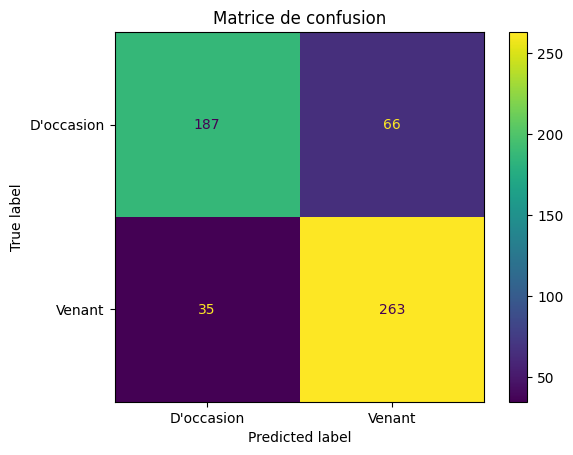

In [38]:
# matrice de confusion
heatmap_conf_matr(knn_model)

#### <font color = 'teal'>Logistic Regression<font>

In [39]:
# Recherche des paramètres optimaux pour la Logistic Regression
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
# dictionnaire des params
params_lg = {"C": np.logspace(-3, 3, 7), "penalty": ['l2'],
             "solver": ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga']}
# instantier le modèle Logistic Regression
lg = LogisticRegression(max_iter=1000)
# instantier le modèle gridsearch
grid_lg = GridSearchCV(estimator=lg, param_grid=params_lg, cv=5)
# entrainer le modèle
grid_lg.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03]),
                         'penalty': ['l2'],
                         'solver': ['lbfgs', 'liblinear', 'newton-cg', 'sag',
                                    'saga']})

In [40]:
# afficher les paramètres optimaux
grid_lg.best_params_

{'C': np.float64(0.01), 'penalty': 'l2', 'solver': 'lbfgs'}

In [41]:
from sklearn.linear_model import LogisticRegression
# Entrainer la Logistic Regression en utilisant les paramètres optimaux trouvés par GridSearchCV
lg_model = LogisticRegression(max_iter=1000, **grid_lg.best_params_)
lg_model.fit(x_train, y_train)

LogisticRegression(C=np.float64(0.01), max_iter=1000)

##### <font color ='bisque'>Evaluation - Logistic Regression<font>

In [42]:
# Accuracy, F1, Precision, Recall sur les données de validation
acc_lg, f1_lg, prec_lg, rec_lg = evaluation(lg_model)
print(f"Accuracy : {acc_lg:.3f} -- F1 score : {f1_lg:.3f} -- Precision : {prec_lg:.3f} -- Recall : {rec_lg:.3f}")

Accuracy : 0.795 -- F1 score : 0.811 -- Precision : 0.807 -- Recall : 0.815


In [43]:
# Vérifier le comportement du modèle sur les données d'entrainement (sur/sous-apprentissage)
evaluation_train(lg_model)

F1 score sur les données train :  0.798


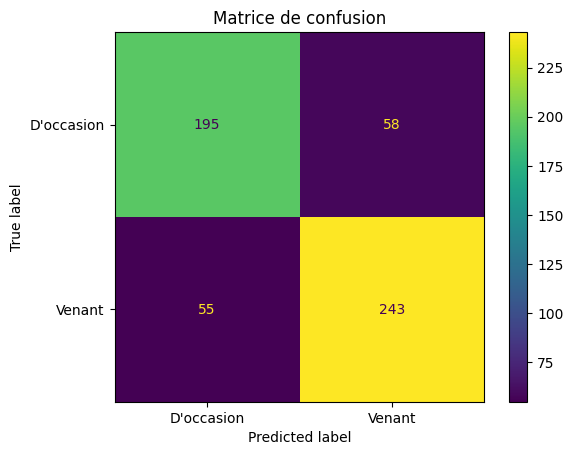

In [44]:
# matrice de confusion
heatmap_conf_matr(lg_model)

#### <font color = 'teal'>Support Vector Machine (SVM)<font>

In [62]:
# Recherche des paramètres optimaux pour le SVM
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
# dictionnaire des params
params_svm = {'C': np.logspace(-1, 3, 5), 'kernel': ['linear', 'rbf', 'poly']}
# instantier le modèle SVM
svm = SVC()
# instantier le modèle gridsearch
grid_svm = GridSearchCV(estimator=svm, param_grid=params_svm, cv=5)
# entrainer le modèle
grid_svm.fit(x_train, y_train)

In [ ]:
# afficher les paramètres optimaux
grid_svm.best_params_

In [48]:
from sklearn.svm import SVC
# Entrainer le SVM en utilisant les paramètres optimaux trouvés par GridSearchCV
svm_model = SVC(
    C=10,
    kernel='rbf',
    gamma='scale',
    random_state=42)
svm_model.fit(x_train, y_train)

SVC(C=10, random_state=42)

##### <font color ='bisque'>Evaluation - Support Vector Machine (SVM)<font>

In [49]:
# Accuracy, F1, Precision, Recall sur les données de validation
acc_svm, f1_svm, prec_svm, rec_svm = evaluation(svm_model)
print(f"Accuracy : {acc_svm:.3f} -- F1 score : {f1_svm:.3f} -- Precision : {prec_svm:.3f} -- Recall : {rec_svm:.3f}")

Accuracy : 0.811 -- F1 score : 0.833 -- Precision : 0.799 -- Recall : 0.869


In [50]:
# Vérifier le comportement du modèle sur les données d'entrainement (sur/sous-apprentissage)
evaluation_train(svm_model)

F1 score sur les données train :  0.823


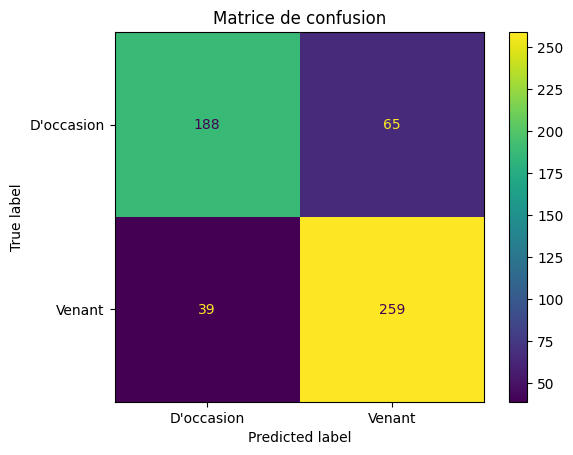

In [51]:
# matrice de confusion
heatmap_conf_matr(svm_model)

#### <font color = 'teal'>Decision Tree<font>

In [52]:
# Recherche des paramètres optimaux pour le Decision Tree
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
# dictionnaire des params
params_dt = {'criterion': ['gini', 'entropy'], 'max_depth': list(np.arange(3, 15))}
# instantier le modèle Decision Tree
dt = DecisionTreeClassifier()
# instantier le modèle gridsearch
grid_dt = GridSearchCV(estimator=dt, param_grid=params_dt, cv=5)
# entrainer le modèle
grid_dt.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [np.int64(3), np.int64(4), np.int64(5),
                                       np.int64(6), np.int64(7), np.int64(8),
                                       np.int64(9), np.int64(10), np.int64(11),
                                       np.int64(12), np.int64(13),
                                       np.int64(14)]})

In [53]:
# afficher les paramètres optimaux
grid_dt.best_params_

{'criterion': 'gini', 'max_depth': np.int64(4)}

In [54]:
from sklearn.tree import DecisionTreeClassifier
# Entrainer le Decision Tree en utilisant les paramètres optimaux trouvés par GridSearchCV
dt_model = DecisionTreeClassifier(**grid_dt.best_params_)
dt_model.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=np.int64(4))

##### <font color ='bisque'>Evaluation - Decision Tree<font>

In [55]:
# Accuracy, F1, Precision, Recall sur les données de validation
acc_dt, f1_dt, prec_dt, rec_dt = evaluation(dt_model)
print(f"Accuracy : {acc_dt:.3f} -- F1 score : {f1_dt:.3f} -- Precision : {prec_dt:.3f} -- Recall : {rec_dt:.3f}")

Accuracy : 0.809 -- F1 score : 0.831 -- Precision : 0.799 -- Recall : 0.866


In [56]:
# Vérifier le comportement du modèle sur les données d'entrainement (sur/sous-apprentissage)
evaluation_train(dt_model)

F1 score sur les données train :  0.830


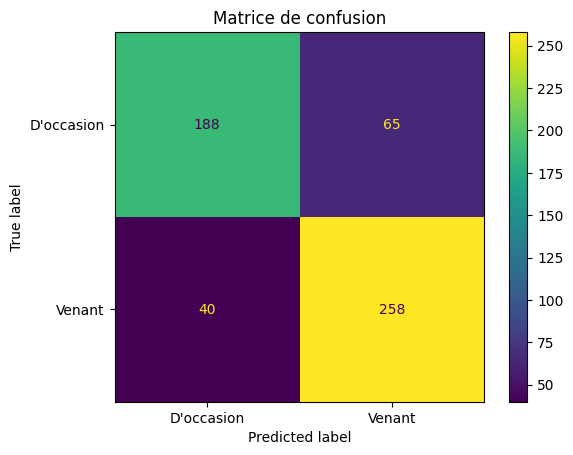

In [57]:
# matrice de confusion
heatmap_conf_matr(dt_model)

In [58]:
# barplot de l'importance des variables
barplot_feat_imp(dt_model)

#### <font color = 'teal'>Random Forest<font>

In [61]:
# Recherche des paramètres optimaux pour le Random Forest
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
# dictionnaire des params
params_rf = {
    'n_estimators': list(np.arange(10, 100, 10)),
    'max_depth': list(np.arange(3, 15)),
    'criterion': ['gini', 'entropy']
}
# instantier le modèle Random Forest
rf = RandomForestClassifier()
# instantier le modèle gridsearch
grid_rf = GridSearchCV(estimator=rf, param_grid=params_rf, cv=5)
# entrainer le modèle
grid_rf.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [np.int64(3), np.int64(4), np.int64(5),
                                       np.int64(6), np.int64(7), np.int64(8),
                                       np.int64(9), np.int64(10), np.int64(11),
                                       np.int64(12), np.int64(13),
                                       np.int64(14)],
                         'n_estimators': [np.int64(10), np.int64(20),
                                          np.int64(30), np.int64(40),
                                          np.int64(50), np.int64(60),
                                          np.int64(70), np.int64(80),
                                          np.int64(90)]})

In [63]:
# afficher les paramètres optimaux
grid_rf.best_params_

{'criterion': 'gini', 'max_depth': np.int64(7), 'n_estimators': np.int64(70)}

In [64]:
from sklearn.ensemble import RandomForestClassifier
# Entrainer le Random Forest en utilisant les paramètres optimaux trouvés par GridSearchCV
rf_model = RandomForestClassifier(**grid_rf.best_params_)
rf_model.fit(x_train, y_train)

RandomForestClassifier(max_depth=np.int64(7), n_estimators=np.int64(70))

##### <font color ='bisque'>Evaluation - Random Forest<font>

In [65]:
# Accuracy, F1, Precision, Recall sur les données de validation
acc_rf, f1_rf, prec_rf, rec_rf = evaluation(rf_model)
print(f"Accuracy : {acc_rf:.3f} -- F1 score : {f1_rf:.3f} -- Precision : {prec_rf:.3f} -- Recall : {rec_rf:.3f}")

Accuracy : 0.815 -- F1 score : 0.839 -- Precision : 0.793 -- Recall : 0.889


In [66]:
# Vérifier le comportement du modèle sur les données d'entrainement (sur/sous-apprentissage)
evaluation_train(rf_model)

F1 score sur les données train :  0.852


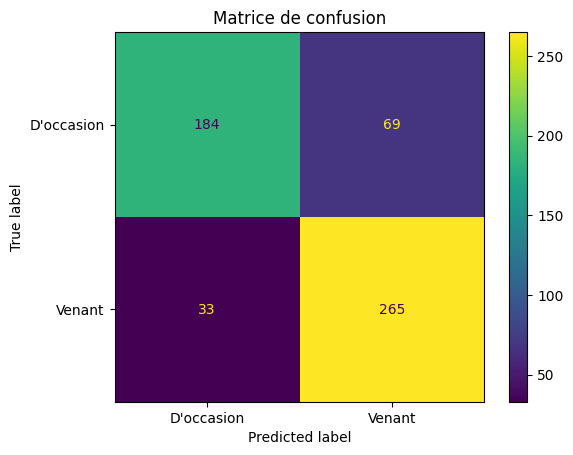

In [67]:
# matrice de confusion
heatmap_conf_matr(rf_model)

In [68]:
# barplot de l'importance des variables
barplot_feat_imp(rf_model)

#### <font color = 'teal'>Gradient Boosting<font>

In [ ]:
# Recherche des paramètres optimaux pour le Gradient Boosting
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
# dictionnaire des params
params_gb = {"n_estimators": list(np.arange(10, 100, 10)),
             "max_depth": list(np.arange(3, 15))}
# instantier le modèle Gradient Boosting
gb = GradientBoostingClassifier()
# instantier le modèle gridsearch
grid_gb = GridSearchCV(estimator=gb, param_grid=params_gb, cv=5)
# entrainer le modèle
grid_gb.fit(x_train, y_train)

In [ ]:
# afficher les paramètres optimaux
grid_gb.best_params_

In [69]:
from sklearn.ensemble import GradientBoostingClassifier
# Entrainer le Gradient Boosting en utilisant les paramètres optimaux trouvés par GridSearchCV
#gb_model = GradientBoostingClassifier(**grid_gb.best_params_) pas utilisé a cause de la complexité
gb_model = GradientBoostingClassifier(
    n_estimators=200,       # nombre d'arbres : compense un learning_rate plus faible
    learning_rate=0.05,     # pas d'apprentissage modéré -> meilleure généralisation
    max_depth=4,            # arbres peu profonds = standard pour le boosting
    subsample=0.8,          # stochastic gradient boosting -> réduit l'overfitting
    max_features='sqrt',    # réduit la variance, accélère l'entrainement
    random_state=42)
gb_model.fit(x_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, max_depth=4, max_features='sqrt',
                           n_estimators=200, random_state=42, subsample=0.8)

##### <font color ='bisque'>Evaluation - Gradient Boosting<font>

In [70]:
# Accuracy, F1, Precision, Recall sur les données de validation
acc_gb, f1_gb, prec_gb, rec_gb = evaluation(gb_model)
print(f"Accuracy : {acc_gb:.3f} -- F1 score : {f1_gb:.3f} -- Precision : {prec_gb:.3f} -- Recall : {rec_gb:.3f}")

Accuracy : 0.817 -- F1 score : 0.838 -- Precision : 0.803 -- Recall : 0.876


In [71]:
# Vérifier le comportement du modèle sur les données d'entrainement (sur/sous-apprentissage)
evaluation_train(gb_model)

F1 score sur les données train :  0.860


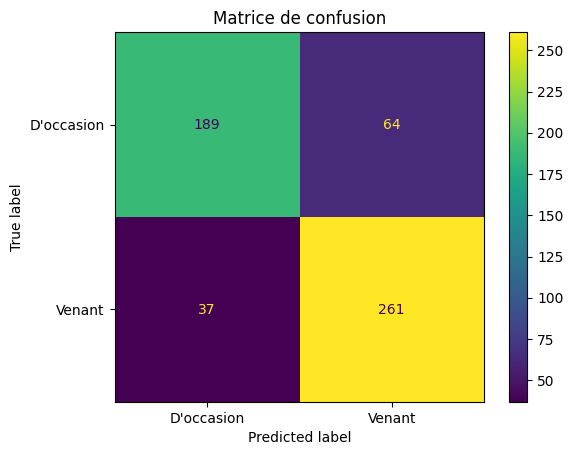

In [72]:
# matrice de confusion
heatmap_conf_matr(gb_model)

In [73]:
# barplot de l'importance des variables
barplot_feat_imp(gb_model)

#### <font color = 'teal'>XGBoost<font>

In [74]:
# Recherche des paramètres optimaux pour XGBoost
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
# dictionnaire des params
params_xgb = {"n_estimators": list(np.arange(10, 100, 10)),
              "max_depth": list(np.arange(3, 15))}
# instantier le modèle XGBoost
xgb = XGBClassifier(eval_metric='mlogloss')
# instantier le modèle gridsearch
grid_xgb = GridSearchCV(estimator=xgb, param_grid=params_xgb, cv=5)
# entrainer le modèle
grid_xgb.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constrain...
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'max_depth': [np.int64(3), np.int64(4), np.int64(5),
                                       np.int64(6), np.int64(7), np.int64(8),
                                       np.int64(9), np.int64(10), np.int64(11),
                                       np.int64(12), np.int64(13),
                                       np.int64(14)],
                         'n_estimators': [np.int64(10), np.int64(20),
                                          np.int64(30), np.int64(40),
                                          np.int64(50), np.int64(60),
                                          np.int64(70), np.int64(80),
                                          np.int64(90)]})

In [75]:
# afficher les paramètres optimaux
grid_xgb.best_params_

{'max_depth': np.int64(4), 'n_estimators': np.int64(20)}

In [76]:
from xgboost import XGBClassifier
# Entrainer XGBoost en utilisant les paramètres optimaux trouvés par GridSearchCV
xgb_model = XGBClassifier(eval_metric='mlogloss', **grid_xgb.best_params_)
xgb_model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=np.int64(4), max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=np.int64(20), n_jobs=None,
              num_parallel_tree=None, ...)

##### <font color ='bisque'>Evaluation - XGBoost<font>

In [77]:
# Accuracy, F1, Precision, Recall sur les données de validation
acc_xgb, f1_xgb, prec_xgb, rec_xgb = evaluation(xgb_model)
print(f"Accuracy : {acc_xgb:.3f} -- F1 score : {f1_xgb:.3f} -- Precision : {prec_xgb:.3f} -- Recall : {rec_xgb:.3f}")

Accuracy : 0.831 -- F1 score : 0.852 -- Precision : 0.812 -- Recall : 0.896


In [78]:
# Vérifier le comportement du modèle sur les données d'entrainement (sur/sous-apprentissage)
evaluation_train(xgb_model)

F1 score sur les données train :  0.848


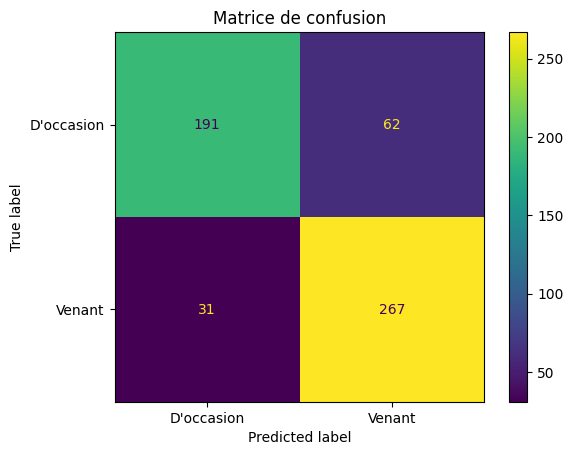

In [79]:
# matrice de confusion
heatmap_conf_matr(xgb_model)

In [80]:
# barplot de l'importance des variables
barplot_feat_imp(xgb_model)

### <font color = 'gold'>Comparaison des 7 modèles<font>

In [81]:
# Diagramme en barre de comparaison des F1-scores des 7 modèles
models_names = ['KNN', 'LG', 'SVM', 'DT', 'RF', 'GB', 'XGB']
f1_scores = [f1_knn, f1_lg, f1_svm, f1_dt, f1_rf, f1_gb, f1_xgb]
fig = px.bar(x=models_names, y=f1_scores, color=models_names, text_auto=True)
fig.show()

In [82]:
# Sélection automatique du modèle le plus performant (F1-score sur validation)
models_dict = {
    'KNN': knn_model, 'LG': lg_model, 'SVM': svm_model, 'DT': dt_model,
    'RF': rf_model, 'GB': gb_model, 'XGB': xgb_model
}
scores_dict = dict(zip(models_names, f1_scores))
best_name = max(scores_dict, key=scores_dict.get)
best_model = models_dict[best_name]
print(f"Le meilleur modèle est : {best_name} avec un F1-score de {scores_dict[best_name]:.3f}")

Le meilleur modèle est : XGB avec un F1-score de 0.852


In [83]:
# télécharger le modèle le plus performant
jb.dump(best_model, 'XGB_model.joblib')

['XGB_model.joblib']

### <font color ='bisque'>Tester le modèle le plus performant<font>

In [84]:
# echantillons de 10 sur les données test
x_test_10 = x_test[:10]
y_test_10 = y_test[:10]
y_pred_10 = best_model.predict(x_test_10)
for i in range(10):
    print(f"Prédiction {i+1} : {class_names[int(y_pred_10[i])]} |  True Label : {class_names[int(y_test_10[i])]} ")

Prédiction 1 : D'occasion |  True Label : D'occasion 
Prédiction 2 : Venant |  True Label : Venant 
Prédiction 3 : D'occasion |  True Label : D'occasion 
Prédiction 4 : Venant |  True Label : Venant 
Prédiction 5 : D'occasion |  True Label : Venant 
Prédiction 6 : D'occasion |  True Label : D'occasion 
Prédiction 7 : Venant |  True Label : Venant 
Prédiction 8 : Venant |  True Label : D'occasion 
Prédiction 9 : D'occasion |  True Label : Venant 
Prédiction 10 : D'occasion |  True Label : D'occasion 


### <font color = 'bisque'>Déploiement du modèle avec Gradio<font>

In [85]:
!pip install gradio

In [88]:
# Fonction de prédiction
import gradio as gr
import joblib as jb
import pandas as pd
import numpy as np

# importer les encodeurs, les valeurs uniques, le normaliseur et le meilleur modèle
encoders = jb.load('encoders.joblib')
uniques = jb.load('uniques.joblib')
scaler = jb.load('scaler.joblib')
best_model = jb.load('XGB_model.joblib')

# noms des classes (dernière variable catégorielle = Etat)
class_names = uniques[-1]

# fonction de prédiction simple
def Pred_func(marque, annee, transmission, quartier, prix):
    # Encoder les variables catégorielles (Marque, Transmission, Quartier)
    marque = encoders[0].transform([marque])[0]
    transmission = encoders[1].transform([transmission])[0]
    quartier = encoders[2].transform([quartier])[0]

    # vecteur des valeurs (même ordre que x lors de l'entrainement)
    x_new = np.array([marque, annee, transmission, quartier, prix])
    x_new = x_new.reshape(1, -1)
    # Normaliser les données
    x_new = scaler.transform(x_new)
    # Prédire
    y_pred = best_model.predict(x_new)
    return class_names[int(y_pred[0])]

In [89]:
# Fonction de prédiction multiple (fichier CSV)
def Pred_func_csv(file):
    df = pd.read_csv(file)
    predictions = []
    for row in df.iloc[:, :].values:
        y_pred = Pred_func(row[0], row[1], row[2], row[3], row[4])
        predictions.append(y_pred)

    df['Etat'] = predictions
    df.to_csv('predictions.csv', index=False)
    return 'predictions.csv'

In [90]:
# définir les blocks
demo = gr.Blocks(theme='shivi/calm_seafoam')

# Créer les inputs (même ordre que x : Marque, Année, Transmission, Quartier, Prix)
inputs = [gr.Dropdown(choices=uniques[0], label='Marque'),
          gr.Number(label='Année'),
          gr.Dropdown(choices=uniques[1], label='Transmission'),
          gr.Dropdown(choices=uniques[2], label='Quartier'),
          gr.Number(label='Prix')]
outputs = gr.Textbox(label='Etat du véhicule')

interface1 = gr.Interface(fn=Pred_func,
                           inputs=inputs,
                           outputs=outputs,
                           title="Prédire l\'état d\'un véhicule avec une entrée",
                           description="Ce modèle prédit si un véhicule est Occasion ou Venant à partir de la marque, l\'année, la transmission, le quartier et le prix.")

interface2 = gr.Interface(fn=Pred_func_csv,
                           inputs=gr.File(label='Importer un fichier csv'),
                           outputs=gr.File(label='Télécharger un fichier csv'),
                           title="Prédire l\'état de plusieurs véhicules",
                           description="Ce modèle prédit si un véhicule est Occasion ou Venant à partir de la marque, l\'année, la transmission, le quartier et le prix.")

with demo:
    gr.TabbedInterface([interface1, interface2], ['Prédiction simple', 'Prédiction multiple'])

demo.launch(share=True)

theme_schema%400.0.1.json: 0.00B [00:00, ?B/s]

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://3ed23de5d9ad3c7689.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
